In [1]:
import sys
!{sys.executable} -m pip install --upgrade matplotlib matplotlib-inline

In [1]:
import sys
print(sys.executable)

import scanpy as sc
print(sc.__version__)

/home/FCAM/nlippai/.conda/envs/scanpy_env/bin/python
1.11.5


/tmp/ipykernel_533686/2390774583.py:5: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [2]:
import anndata as ad

In [3]:
adata1 = sc.read_10x_h5(
    "/home/FCAM/nlippai/ISG/finalProject/results/01_cellranger/clone1/outs/filtered_feature_bc_matrix.h5"
)
adata1.var_names_make_unique()
adata1.obs["clone"] = "clone1"

adata2 = sc.read_10x_h5(
    "/home/FCAM/nlippai/ISG/finalProject/results/01_cellranger/clone2/outs/filtered_feature_bc_matrix.h5"
)
adata2.var_names_make_unique()
adata2.obs["clone"] = "clone2"

adata3 = sc.read_10x_h5(
    "/home/FCAM/nlippai/ISG/finalProject/results/01_cellranger/clone3/clone3/outs/filtered_feature_bc_matrix.h5"
)
adata3.var_names_make_unique()
adata3.obs["clone"] = "clone3"

adata4 = sc.read_10x_h5(
    "/home/FCAM/nlippai/ISG/finalProject/results/01_cellranger/clone4/clone4/outs/filtered_feature_bc_matrix.h5"
)
adata4.var_names_make_unique()
adata4.obs["clone"] = "clone4"

/home/FCAM/nlippai/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/FCAM/nlippai/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/FCAM/nlippai/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/FCAM/nlippai/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/FCAM/nlippai/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not un

In [4]:
adata1.obs_names = "clone1_" + adata1.obs_names
adata2.obs_names = "clone2_" + adata2.obs_names
adata3.obs_names = "clone3_" + adata3.obs_names
adata4.obs_names = "clone4_" + adata4.obs_names

In [5]:
adata = ad.concat(
    [adata1, adata2, adata3, adata4],
    join="outer",
    label="clone_concat",
    keys=["clone1", "clone2", "clone3", "clone4"],
    index_unique=None
)

In [6]:
adata.var_names.is_unique

True

In [7]:
adata.var.head()

""
Xkr4
Gm1992
Gm19938
Gm37381
Rp1


In [8]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")

In [9]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

In [10]:
adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt", "clone"]].head()

,n_genes_by_counts,total_counts,pct_counts_mt,clone
clone1_AAACCCAAGAGTGTGC-1,2446,4708.0,5.480034,clone1
clone1_AAACCCAAGATGATTG-1,2052,3991.0,6.013531,clone1
clone1_AAACCCAAGCACCCAC-1,2430,4463.0,3.069684,clone1
clone1_AAACCCAAGCATCTTG-1,2941,6173.0,3.434311,clone1
clone1_AAACCCAAGCGGCTCT-1,2413,4463.0,2.531929,clone1


In [13]:
import matplotlib.pyplot as plt

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="clone",
    jitter=0.4,
    multi_panel=True,
    show=False
)

plt.savefig("qc_violin_by_clone.png", dpi=300, bbox_inches="tight")
plt.close()

In [11]:
adata_filt = adata[
    (adata.obs["n_genes_by_counts"] > 500) &
    (adata.obs["n_genes_by_counts"] < 8000) &
    (adata.obs["total_counts"] < 75000) &
    (adata.obs["pct_counts_mt"] < 20)
].copy()

In [12]:
print("Before QC:")
print(adata.obs["clone"].value_counts())

print("After QC:")
print(adata_filt.obs["clone"].value_counts())

Before QC:
clone
clone1    37900
clone4    31487
clone2    24564
clone3    21828
Name: count, dtype: int64
After QC:
clone
clone1    37678
clone4    31176
clone2    24112
clone3    21275
Name: count, dtype: int64


In [13]:
retention = (
    adata_filt.obs["clone"].value_counts() /
    adata.obs["clone"].value_counts()
)

print(retention)

clone
clone1    0.994142
clone4    0.990123
clone2    0.981599
clone3    0.974666
Name: count, dtype: float64


In [18]:
import matplotlib.pyplot as plt

sc.pl.violin(
    adata_filt,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="clone",
    jitter=0.4,
    multi_panel=True,
    show=False
)

plt.savefig("qc_violin_after_filtering.png", dpi=300, bbox_inches="tight")
plt.close()

In [20]:
adata_filt.obs.columns

Index(['clone', 'clone_concat', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt'],
      dtype='object')

In [14]:
import pandas as pd

vireo1 = pd.read_csv("/home/FCAM/nlippai/ISG/finalProject/results/03_vireo/clone1/donor_ids.tsv", sep="\t")
vireo2 = pd.read_csv("/home/FCAM/nlippai/ISG/finalProject/results/03_vireo/clone2/donor_ids.tsv", sep="\t")
vireo3 = pd.read_csv("/home/FCAM/nlippai/ISG/finalProject/results/03_vireo/clone3/donor_ids.tsv", sep="\t")
vireo4 = pd.read_csv("/home/FCAM/nlippai/ISG/finalProject/results/03_vireo/clone4/donor_ids.tsv", sep="\t")

vireo1["cell"] = "clone1_" + vireo1["cell"]
vireo2["cell"] = "clone2_" + vireo2["cell"]
vireo3["cell"] = "clone3_" + vireo3["cell"]
vireo4["cell"] = "clone4_" + vireo4["cell"]

vireo_all = pd.concat([vireo1, vireo2, vireo3, vireo4], axis=0)
vireo_all = vireo_all.set_index("cell")

In [15]:
adata_filt.obs = adata_filt.obs.merge(
    vireo_all,
    left_index=True,
    right_index=True,
    how="left"
)

In [16]:
adata_vireo_filt = adata_filt[
    (adata_filt.obs["prob_max"] > 0.9) &
    (~adata_filt.obs["donor_id"].isin(["doublet", "unassigned"]))
].copy()

In [17]:
sc.pp.normalize_total(adata_vireo_filt, target_sum=1e4)
sc.pp.log1p(adata_vireo_filt)

adata_vireo_filt.raw = adata_vireo_filt.copy()

sc.pp.highly_variable_genes(
    adata_vireo_filt,
    n_top_genes=3000,
    batch_key="clone"
)

adata_vireo_filt = adata_vireo_filt[:, adata_vireo_filt.var["highly_variable"]].copy()

sc.pp.scale(adata_vireo_filt, max_value=10)
sc.tl.pca(adata_vireo_filt, n_comps=50)

/home/FCAM/nlippai/.conda/envs/scanpy_env/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [18]:
import harmonypy as hm
import numpy as np

In [19]:
ho = hm.run_harmony(
    adata_vireo_filt.obsm["X_pca"],
    adata_vireo_filt.obs,
    vars_use="clone"
)

2026-05-06 14:11:02,930 - harmonypy - INFO - Running Harmony
2026-05-06 14:11:02,931 - harmonypy - INFO -   Parameters:
2026-05-06 14:11:02,931 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-06 14:11:02,931 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-06 14:11:02,931 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-06 14:11:02,932 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-06 14:11:02,932 - harmonypy - INFO -     nclust: 100
2026-05-06 14:11:02,932 - harmonypy - INFO -     block_size: 0.05
2026-05-06 14:11:02,933 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-06 14:11:02,933 - harmonypy - INFO -     theta: [2. 2. 2. 2.]
2026-05-06 14:11:02,933 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-06 14:11:02,934 - harmonypy - INFO -     verbose: True
2026-05-06 14:11:02,934 - harmonypy - INFO -     random_state: 0
2026-05-06 14:11:02,934 - harmonypy - INFO -   Data: 50 PCs × 65612 cells
2026-05-06 14:11:02,934 - harmonypy - INFO -

In [20]:
Z = ho.Z_corr

print(type(Z))
print(np.asarray(Z).shape)
print("n cells:", adata_vireo_filt.n_obs)

<class 'numpy.ndarray'>
(65612, 50)
n cells: 65612


In [21]:
adata_vireo_filt.obsm["X_pca_harmony"] = ho.Z_corr

adata_vireo_filt.obsm["X_pca_harmony"].shape

(65612, 50)

In [23]:
sc.pp.neighbors(
    adata_vireo_filt,
    use_rep="X_pca_harmony",
    n_neighbors=15
)

sc.tl.umap(adata_vireo_filt)

/home/FCAM/nlippai/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
sc.tl.leiden(adata_vireo_filt, resolution=0.5)

In [25]:
adata_vireo_filt.obs["leiden"].value_counts()

leiden
0     9800
1     9002
2     8551
3     7251
4     6050
5     5305
6     4345
7     4081
8     4077
9     3140
10    3105
11     577
12     328
Name: count, dtype: int64

In [32]:
adata_vireo_filt.write("all_clones_vireo_filtered_harmony_leiden.h5ad")

In [33]:
print(adata_vireo_filt.obsm.keys())
print(adata_vireo_filt.obs.columns)

KeysView(AxisArrays with keys: X_pca, X_pca_harmony, X_umap)
Index(['clone', 'clone_concat', 'n_genes_by_counts', 'total_counts',
       'total_counts_mt', 'pct_counts_mt', 'donor_id', 'prob_max',
       'prob_doublet', 'n_vars', 'best_singlet', 'best_doublet',
       'doublet_logLikRatio', 'leiden'],
      dtype='object')


In [34]:
import matplotlib.pyplot as plt

sc.pl.umap(
    adata_vireo_filt,
    color="leiden",
    legend_loc="on data",
    show=False
)
plt.savefig("umap_leiden.png", dpi=300, bbox_inches="tight")
plt.close()

sc.pl.umap(
    adata_vireo_filt,
    color="clone",
    show=False
)
plt.savefig("umap_clone.png", dpi=300, bbox_inches="tight")
plt.close()

sc.pl.umap(
    adata_vireo_filt,
    color="donor_id",
    show=False
)
plt.savefig("umap_donor_id.png", dpi=300, bbox_inches="tight")
plt.close()

In [35]:
import pandas as pd

clone_comp = pd.crosstab(
    adata_vireo_filt.obs["leiden"],
    adata_vireo_filt.obs["clone"],
    normalize="index"
)

clone_comp

clone,clone1,clone2,clone3,clone4
leiden,,,,
0,0.210204,0.263878,0.180714,0.345204
1,0.157187,0.255832,0.232504,0.354477
2,0.115659,0.105602,0.288738,0.490001
3,0.200524,0.315681,0.192249,0.291546
4,0.335207,0.281322,0.169587,0.213884
5,0.197738,0.098586,0.268615,0.435061
6,0.168239,0.244879,0.221864,0.365017
7,0.422200,0.234746,0.084538,0.258515
8,0.090998,0.248958,0.294825,0.365220


In [36]:
donor_comp = pd.crosstab(
    adata_vireo_filt.obs["leiden"],
    adata_vireo_filt.obs["donor_id"],
    normalize="index"
)

donor_comp

donor_id,CAST_EiJ,MOLF_EiJ,PWK_PhJ,SPRET_EiJ
leiden,,,,
0,0.135510,0.321735,0.166020,0.376735
1,0.145079,0.315819,0.251055,0.288047
2,0.307917,0.137762,0.204421,0.349901
3,0.201489,0.328231,0.199007,0.271273
4,0.231901,0.281653,0.265289,0.221157
5,0.238454,0.238266,0.231668,0.291612
6,0.184810,0.289298,0.266743,0.259148
7,0.250429,0.184759,0.300417,0.264396
8,0.103262,0.480746,0.365710,0.050282


In [37]:
import matplotlib.pyplot as plt

sc.pl.violin(
    adata_vireo_filt,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="leiden",
    jitter=0.2,
    multi_panel=True,
    show=False
)

plt.savefig("qc_by_leiden.png", dpi=300, bbox_inches="tight")
plt.close()

In [26]:
adata_vireo_filt.raw is not None

True

In [39]:
sc.tl.rank_genes_groups(
    adata_vireo_filt,
    groupby="leiden",
    method="wilcoxon"
)

In [34]:
import matplotlib.pyplot as plt

sc.pl.rank_genes_groups(
    adata_vireo_filt,
    n_genes=10,
    sharey=False,
    show=False
)

plt.savefig("rank_genes_groups_leiden.png", dpi=300, bbox_inches="tight")
plt.close()

In [35]:
markers = sc.get.rank_genes_groups_df(
    adata_vireo_filt,
    group=None
)

markers.to_csv("leiden_marker_genes.csv", index=False)

In [36]:
strong_markers = markers[
    (markers["pvals_adj"] < 0.05) &
    (markers["logfoldchanges"] > 0.5)
]

strong_markers.to_csv("leiden_marker_genes_filtered.csv", index=False)

In [26]:
paper_marker_genes_general_clean = {
    "Cortical_identity": [
        "Foxg1", "Emx1"
    ],

    "Progenitors_RGC_IPC": [
        "Pax6", "Sox2", "Nes", "Eomes", "Neurog2"
    ],

    "Cortical_neurons": [
        "Neurod2", "Tbr1", "Reln", "Bcl11b", "Satb2"
    ],

    "Astrocytes": [
        "Gfap", "S100b", "Apoe", "Glul", "Clmn", "Fam107a"
    ],

    "Oligodendrocyte_lineage": [
        "Olig1", "Olig2", "Pdgfra", "Bcas1", "Mbp", "Myrf", "Mag"
    ],

    "Ependymal": [
        "Foxj1", "Pifo"
    ],

    "Off_target_inhibitory": [
        "Dlx6os1", "Gad2"
    ],

    "Cycling": [
        "Mki67", "Top2a"
    ]
}

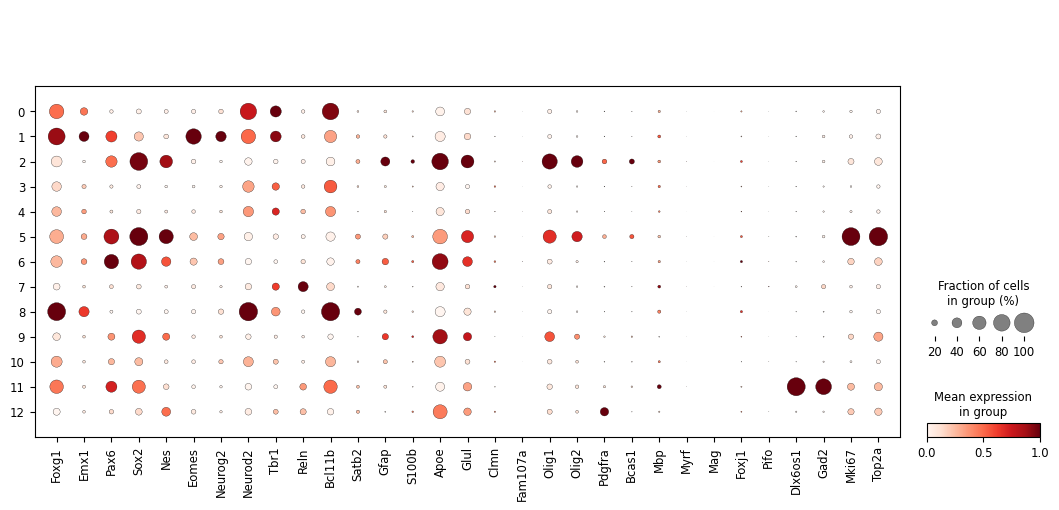

In [40]:
marker_genes_flat = []
for genes in paper_marker_genes_general_clean.values():
    marker_genes_flat.extend(genes)

marker_genes_present = [
    g for g in marker_genes_flat
    if g in adata_vireo_filt.var_names or (
        adata_vireo_filt.raw is not None and g in adata_vireo_filt.raw.var_names
    )
]

sc.pl.dotplot(
    adata_vireo_filt,
    marker_genes_present,
    groupby="leiden",
    use_raw=True,
    standard_scale="var"
)

In [41]:
core_markers = [
    "Foxg1", "Emx1", "Pax6", "Eomes", "Neurog2",
    "Neurod2", "Tbr1", "Bcl11b", "Satb2",
    "Gfap", "Olig2", "Pdgfra", "Mbp", "Mki67"
]

{'mainplot_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

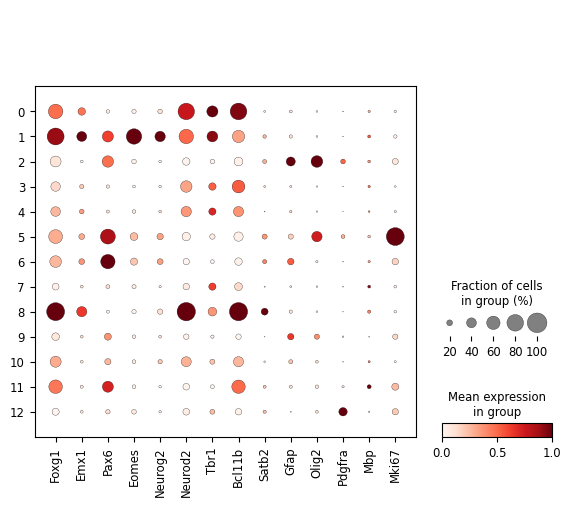

In [47]:
core_markers_present = [
    g for g in core_markers
    if g in adata_vireo_filt.raw.var_names
]

sc.pl.dotplot(
    adata_vireo_filt,
    core_markers_present,
    groupby="leiden",
    use_raw=True,
    standard_scale="var",
    show=False
)

In [48]:
paper_marker_genes = {
    "Telencephalon": ["Foxg1"],
    "Dorsal_telencephalon": ["Emx1"],
    "Radial_glia_RGCs": ["Pax6", "Foxg1", "Emx1"],
    "IPCs": ["Eomes", "Neurog2"],
    "Broad_neurons": ["Neurod2"],
    "Preplate_neurons": ["Tbr1", "Reln", "Rcan2", "Gabra5", "Tmem163", "Cdh18", "Csmd3"],
    "Cortical_projection_neurons": ["Neurod2", "Tbr1", "Reln", "Bcl11b", "Satb2"],
    "Deep_layer_neurons": ["Bcl11b", "Tbr1", "Lmo3", "Pcp4", "Cntn6"],
    "Upper_layer_neurons": ["Satb2", "Cux1", "Pou3f3", "Lhx2", "Pou3f1", "Mdga1"],
    "Inhibitory_off_target": ["Dlx6os1", "Gad2"],
    "Astrocytes": ["Gfap"],
    "Early_astrocytes": ["Egfr", "Etv4", "Grm5"],
    "Mature_astrocytes": ["S100b", "Apoe", "Glul", "Clmn", "Syne1", "Fam107a"],
    "OPCs": ["Olig1", "Olig2", "Pdgfra", "Bcas1", "Cspg4"],
    "Oligodendrocytes": ["Enpp6", "Mbp", "Myrf", "Mag", "Cnp"],
    "Ependymal": ["Foxj1", "Pifo"],
    "Cycling": ["Mki67", "Top2a"]
}

{'mainplot_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

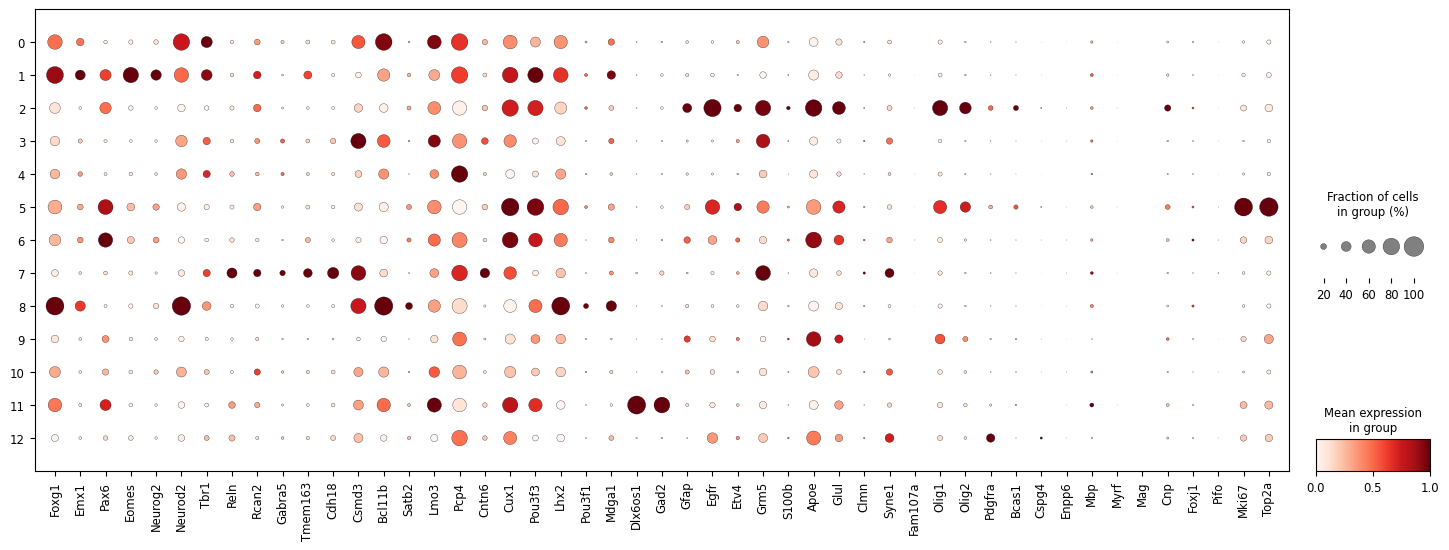

In [50]:
markers_present = []

for category, genes in paper_marker_genes.items():
    for gene in genes:
        if gene in adata_vireo_filt.raw.var_names:
            markers_present.append(gene)

# remove duplicates while preserving order
markers_present = list(dict.fromkeys(markers_present))

import matplotlib.pyplot as plt

sc.pl.dotplot(
    adata_vireo_filt,
    markers_present,
    groupby="leiden",
    use_raw=True,
    standard_scale="var",
    figsize=(18, 6),
    show=False
)

In [30]:
cluster_annotation = {
    "0": "cortical projection neurons",
    "1": "cortical progenitors/IPCs",
    "2": "astrocytes/glial-like",
    "3": "cortical projection neurons",
    "4": "cortical projection neurons",
    "5": "proliferating upper-layer like neurons",
    "6": "RGCs",
    "7": "pre-plate neurons",
    "8": "cortical projection neurons",
    "9": "astrocytes/glial-like",
    "10": "deep layer cortical neurons",
    "11": "spiny projection neurons",
    "12": "OPCs"
}

In [31]:
adata_vireo_filt.obs["cell_type"] = (
    adata_vireo_filt.obs["leiden"]
    .map(cluster_annotation)
    .astype("category")
)

In [32]:
adata_vireo_filt.obs[["leiden", "cell_type"]].head()
adata_vireo_filt.obs["cell_type"].value_counts()

cell_type
cortical projection neurons               27178
astrocytes/glial-like                     11691
cortical progenitors/IPCs                  9002
proliferating upper-layer like neurons     5305
RGCs                                       4345
pre-plate neurons                          4081
deep layer cortical neurons                3105
spiny projection neurons                    577
OPCs                                        328
Name: count, dtype: int64

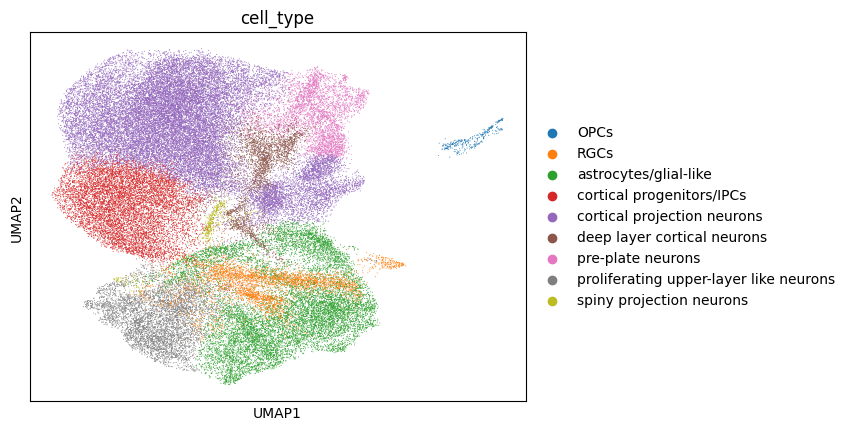

In [33]:
sc.pl.umap(
    adata_vireo_filt,
    color="cell_type",
    legend_loc="right margin"
)